<a href="https://colab.research.google.com/github/JoDepoy-pixel/CompNeuro2026/blob/main/APPM_HW3_1c_2c_4c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

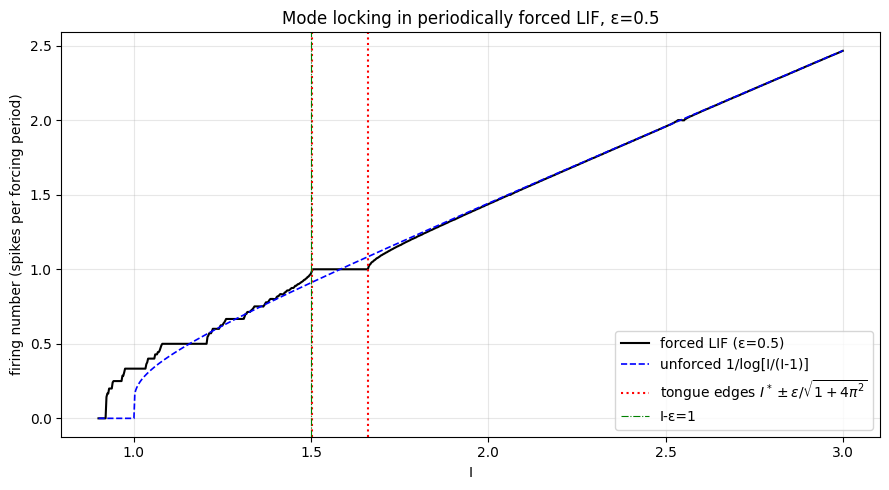

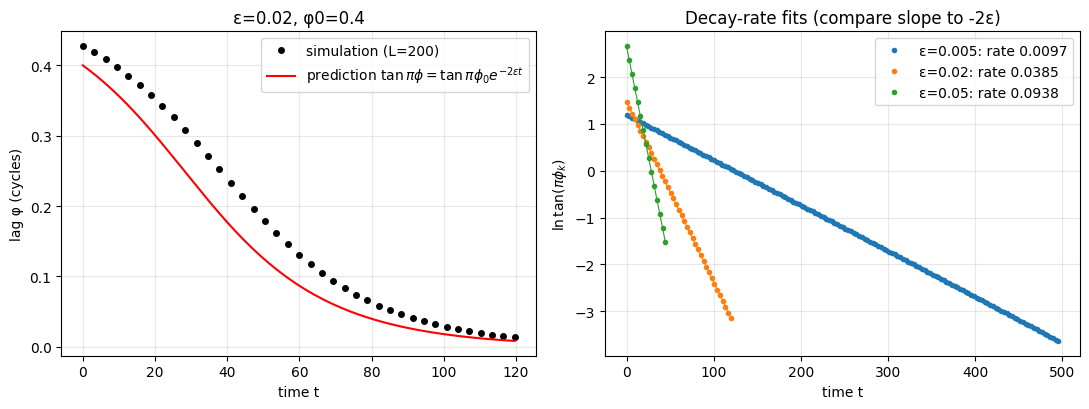

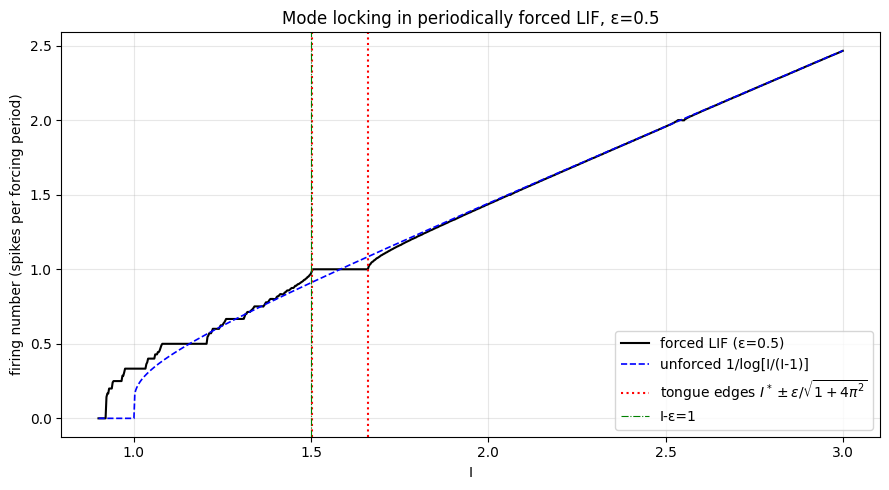

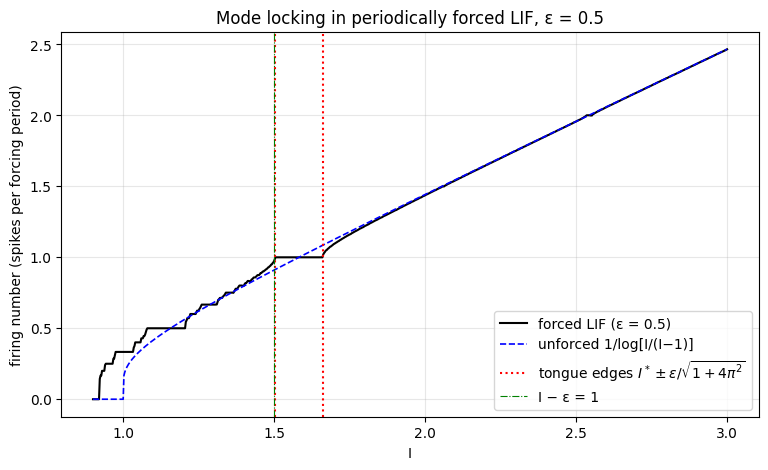

I* = 1.5820
Candidate 1:1 tongue = [1.5034, 1.6606]

Solutions of G(phi) = I* at I = 1.6, eps = 0.5:
  phi = 0.1881, I(phi) = 2.0626, lambda = 0.7141, stable
  phi = 0.7617, I(phi) = 1.1014, lambda = 3.9976, unstable

Simulated firing number at I = 1.6: 1.0000
Spike phases (t mod 1), last 5: [0.1881 0.1881 0.1881 0.1881 0.1881]

Plateaus (firing number = p/q):
  0:1  (value 0.0000)  I in [0.900, 0.920]
  1:2  (value 0.5000)  I in [1.080, 1.205]
  2:3  (value 0.6667)  I in [1.260, 1.310]
  1:1  (value 1.0000)  I in [1.505, 1.660]
  4:3  (value 1.3333)  I in [1.902, 1.905]
  3:2  (value 1.5000)  I in [2.058, 2.062]
  5:3  (value 1.6667)  I in [2.220, 2.220]
  2:1  (value 2.0000)  I in [2.535, 2.553]


In [10]:
#Problem 1C
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ---------------- Parameters ----------------
eps = 0.5
W = 2*np.pi
D = 1 + W**2
Istar = 1/(1 - np.exp(-1))
halfwidth = eps/np.sqrt(D)      # 1:1 tongue: |I - I*| <= eps/sqrt(1+4pi^2)

# G(t) = int_{-inf}^0 e^s I(t+s) ds
def G(t, I):
    return I + eps*(np.sin(W*t) - W*np.cos(W*t))/D

# ---------------- Exact map: next threshold crossing ----------------
def next_spike(Tn, I, tmax=30.0, h=0.01):
    """First t > Tn with v(t) = 1, given v(Tn) = 0 (reset).
    Uses v(t) = G(t) - G(Tn) e^{-(t-Tn)} exactly."""
    c = G(Tn, I)
    f = lambda t: G(t, I) - c*np.exp(-(t - Tn)) - 1.0
    a = Tn
    while a < Tn + tmax:
        ts = a + np.arange(0, 1 + h/2, h)
        fs = f(ts)
        idx = np.where(fs >= 0)[0]
        if idx.size:
            j = idx[0]
            return ts[0] if j == 0 else brentq(f, ts[j-1], ts[j], xtol=1e-13)
        a = ts[-1]
    return None   # never fires

def run(I, Ttot=300.0, Ttrans=100.0):
    """Return (spikes per forcing period after transient, spike times)."""
    T, spikes = 0.0, []
    while True:
        T = next_spike(T, I)
        if T is None or T > Ttot:
            break
        spikes.append(T)
    s = np.array(spikes)
    s = s[s > Ttrans]
    if len(s) < 2:
        return 0.0, s
    return (len(s) - 1)/(s[-1] - s[0]), s

# ---------------- Sweep over I ----------------
Is = np.linspace(0.9, 3.0, 841)
rot = np.array([run(I)[0] for I in Is])

unforced = np.zeros_like(Is)
m = Is > 1
unforced[m] = 1/np.log(Is[m]/(Is[m] - 1))

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(Is, rot, 'k-', lw=1.5, label='forced LIF (ε = 0.5)')
ax.plot(Is, unforced, 'b--', lw=1.2, label='unforced 1/log[I/(I−1)]')
ax.axvline(Istar - halfwidth, color='r', ls=':',
           label=r'tongue edges $I^*\pm\epsilon/\sqrt{1+4\pi^2}$')
ax.axvline(Istar + halfwidth, color='r', ls=':')
ax.axvline(1 + eps, color='g', ls='-.', lw=0.8, label='I − ε = 1')
ax.set(xlabel='I', ylabel='firing number (spikes per forcing period)',
       title='Mode locking in periodically forced LIF, ε = 0.5')
ax.legend(); ax.grid(alpha=.3)
plt.show()

# ---------------- Locked states at I = 1.6 ----------------
I0 = 1.6
ph = np.linspace(0, 1, 200001)
g = G(ph, I0) - Istar
roots = [brentq(lambda x: G(x, I0) - Istar, ph[i], ph[i+1])
         for i in range(len(ph) - 1) if g[i]*g[i+1] < 0]

print(f"I* = {Istar:.4f}")
print(f"Candidate 1:1 tongue = [{Istar-halfwidth:.4f}, {Istar+halfwidth:.4f}]")
print(f"\nSolutions of G(phi) = I* at I = {I0}, eps = {eps}:")
for r in roots:
    Iphi = I0 + eps*np.sin(W*r)
    lam = np.exp(-1)*Iphi/(Iphi - 1)
    print(f"  phi = {r:.4f}, I(phi) = {Iphi:.4f}, lambda = {lam:.4f}, "
          f"{'stable' if Iphi > Istar else 'unstable'}")

rr, sp = run(I0)
print(f"\nSimulated firing number at I = {I0}: {rr:.4f}")
print("Spike phases (t mod 1), last 5:", np.round(sp[-5:] % 1, 4))

# ---------------- Plateaus ----------------
print("\nPlateaus (firing number = p/q):")
for p, q in [(0,1), (1,2), (2,3), (1,1), (4,3), (3,2), (5,3), (2,1), (5,2)]:
    mk = np.abs(rot - p/q) < 1e-3
    if mk.any():
        print(f"  {p}:{q}  (value {p/q:.4f})  I in [{Is[mk].min():.3f}, {Is[mk].max():.3f}]")

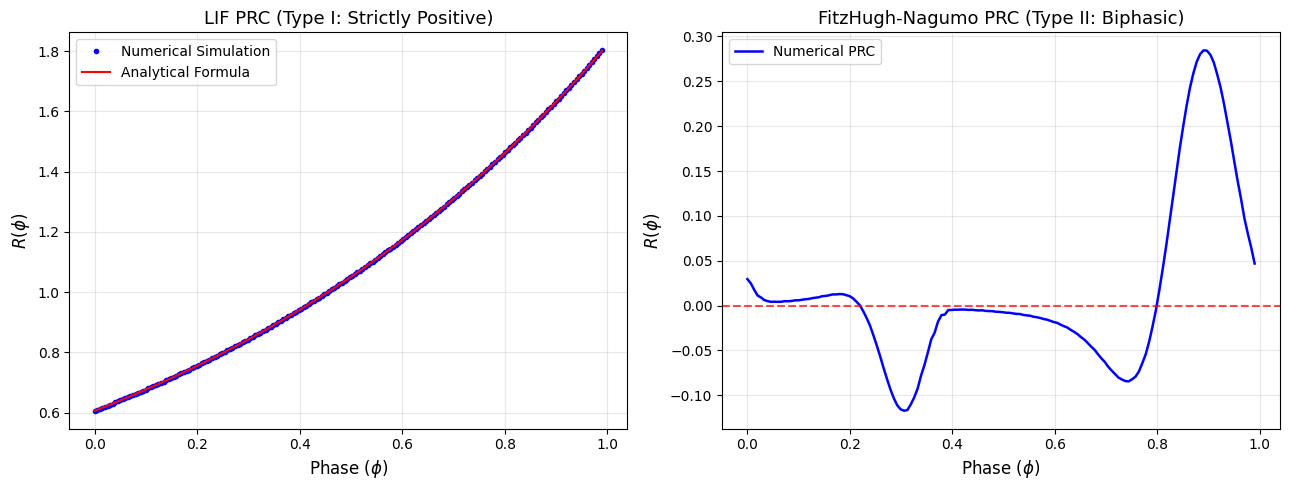

--- LIF Results ---
Natural Period Delta_LIF = 1.0986
Sample T' at phi=0.5: 1.0975

--- FitzHugh-Nagumo Results ---
Natural Period Delta_FHN = 39.4744
Max R(phi) = 0.2845 at phi = 0.890
Min R(phi) = -0.1172 at phi = 0.306


In [1]:
#Problem 2C
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. LIF Model Numerical PRC
# ==========================================
tau, v_r, v_th, I_lif = 1.0, 0.0, 1.0, 1.5
delta_v = 1e-3

# Exact analytical period
Delta_lif = tau * np.log((I_lif * tau - v_r) / (I_lif * tau - v_th))

phi_lif = np.linspace(0, 0.99, 200)
R_lif_num = []
T_prime_lif = []

for phi in phi_lif:
    t_kick = phi * Delta_lif
    v_before = I_lif * tau - (I_lif * tau - v_r) * np.exp(-t_kick / tau)
    v_after = v_before + delta_v

    # Calculate time of next spike T'
    if v_after >= v_th:
        T_prime = t_kick
    else:
        T_prime = t_kick + tau * np.log((I_lif * tau - v_after) / (I_lif * tau - v_th))

    T_prime_lif.append(T_prime)
    # Numerical PRC: R(phi) = (Delta - T') / (Delta * delta_v)
    R_val = (Delta_lif - T_prime) / (Delta_lif * delta_v)
    R_lif_num.append(R_val)

# Analytical PRC formula: R(phi) = tau * exp(phi * Delta / tau) / (Delta * (I * tau - v_r))
R_lif_analytical = (tau * np.exp(phi_lif * Delta_lif / tau)) / (Delta_lif * (I_lif * tau - v_r))


# ==========================================
# 2. FitzHugh-Nagumo Model Numerical PRC
# ==========================================
def fhn_ode(t, y):
    v, w = y
    dv = v - (v**3) / 3.0 - w + 0.5
    dw = 0.08 * (v + 0.7 - 0.8 * w)
    return [dv, dw]

# Event function for upward crossing of v = 0
def v_zero_upward(t, y):
    return y[0]
v_zero_upward.direction = 1

# Step A: Integrate onto stable limit cycle
sol_transient = solve_ivp(fhn_ode, (0, 300), [0.0, 0.0], events=v_zero_upward, rtol=1e-10, atol=1e-10)
crossings = sol_transient.t_events[0]
Delta_fhn = crossings[-1] - crossings[-2]
y_start = sol_transient.y_events[0][-1]  # State vector at v=0 upward crossing

# Step B: Reference trajectory over 1 natural period
t_ref = np.linspace(0, Delta_fhn, 1000)
sol_ref = solve_ivp(fhn_ode, (0, Delta_fhn), y_start, t_eval=t_ref, rtol=1e-10, atol=1e-10)

# Step C: Phase sweep
phi_fhn = np.linspace(0, 0.99, 150)
R_fhn_num = []
T_prime_fhn = []
M_cycles = 5  # Allow M cycles for relaxation back to limit cycle

for phi in phi_fhn:
    t_k = phi * Delta_fhn
    v_k = np.interp(t_k, sol_ref.t, sol_ref.y[0])
    w_k = np.interp(t_k, sol_ref.t, sol_ref.y[1])

    # Apply perturbation delta_v to voltage variable
    y_kicked = [v_k + delta_v, w_k]

    # Integrate forward to measure time of M-th crossing T'
    t_max = (M_cycles + 2) * Delta_fhn
    sol_kicked = solve_ivp(fhn_ode, (0, t_max), y_kicked, events=v_zero_upward, rtol=1e-10, atol=1e-10)

    T_prime = sol_kicked.t_events[0][M_cycles - 1]
    T_prime_fhn.append(T_prime)

    # Expected time across M cycles starting from phase phi
    T_expected = (M_cycles - phi) * Delta_fhn

    # Numerical PRC: R(phi) = (T_expected - T') / (Delta * delta_v)
    R_val = (T_expected - T_prime) / (Delta_fhn * delta_v)
    R_fhn_num.append(R_val)

R_fhn_num = np.array(R_fhn_num)


# ==========================================
# 3. Plotting Results
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LIF Plot
axes[0].plot(phi_lif, R_lif_num, 'bo', markersize=3, label='Numerical Simulation')
axes[0].plot(phi_lif, R_lif_analytical, 'r-', linewidth=1.5, label='Analytical Formula')
axes[0].set_xlabel(r'Phase ($\phi$)', fontsize=12)
axes[0].set_ylabel(r'$R(\phi)$', fontsize=12)
axes[0].set_title('LIF PRC (Type I: Strictly Positive)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# FHN Plot
axes[1].plot(phi_fhn, R_fhn_num, 'b-', linewidth=1.8, label='Numerical PRC')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel(r'Phase ($\phi$)', fontsize=12)
axes[1].set_ylabel(r'$R(\phi)$', fontsize=12)
axes[1].set_title('FitzHugh-Nagumo PRC (Type II: Biphasic)', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Print Summary Statistics
print("--- LIF Results ---")
print(f"Natural Period Delta_LIF = {Delta_lif:.4f}")
print(f"Sample T' at phi=0.5: {T_prime_lif[100]:.4f}")

print("\n--- FitzHugh-Nagumo Results ---")
print(f"Natural Period Delta_FHN = {Delta_fhn:.4f}")
print(f"Max R(phi) = {np.max(R_fhn_num):.4f} at phi = {phi_fhn[np.argmax(R_fhn_num)]:.3f}")
print(f"Min R(phi) = {np.min(R_fhn_num):.4f} at phi = {phi_fhn[np.argmin(R_fhn_num)]:.3f}")

 eps    fitted rate    2*eps    ratio
0.005   0.00975      0.0100   0.9747
0.020   0.03854      0.0400   0.9636
0.050   0.09385      0.1000   0.9385


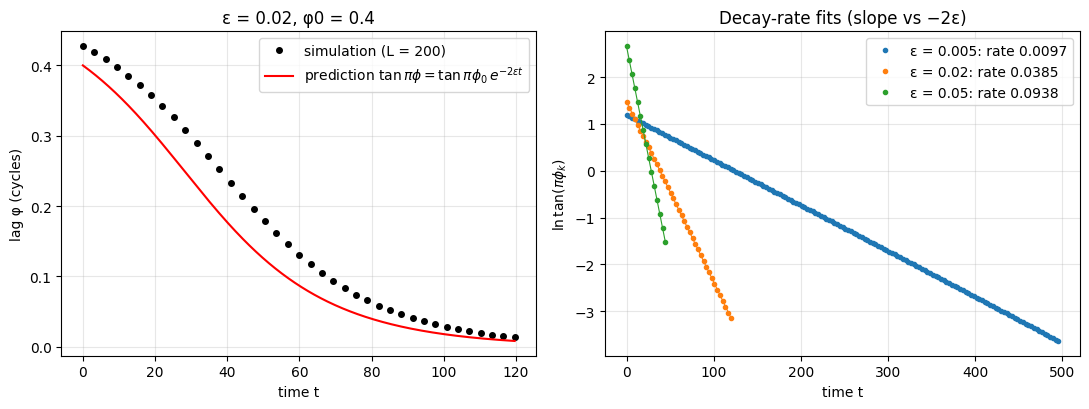

In [11]:
#Problem 4c
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ---------------- Parameters ----------------
L = 200.0       # symmetric cutoff: spike at +L, reset to -L
phi0 = 0.4      # initial lag (fraction of a cycle)

# ---------------- Simulation with event-detected spikes ----------------
def simulate(eps, tend, L=L, phi0=phi0):
    def rhs(t, y):
        v1, v2 = y
        return [1 + v1**2 + eps*(v2 - v1),
                1 + v2**2 + eps*(v1 - v2)]

    ev1 = lambda t, y: y[0] - L
    ev2 = lambda t, y: y[1] - L
    for e in (ev1, ev2):
        e.terminal, e.direction = True, 1

    t = 0.0
    # neuron 1 at reset; neuron 2 on the uncoupled orbit, phase theta2 = 1 - phi0
    y = np.array([-L, -1/np.tan(np.pi*(1 - phi0))])
    s1, s2 = [], []
    while t < tend:
        sol = solve_ivp(rhs, (t, tend), y, events=(ev1, ev2),
                        method='DOP853', rtol=1e-11, atol=1e-11)
        t, y = sol.t[-1], sol.y[:, -1].copy()
        if sol.status != 1:        # reached tend without an event
            break
        if len(sol.t_events[0]):
            s1.append(t); y[0] = -L   # symmetric reset
        if len(sol.t_events[1]):
            s2.append(t); y[1] = -L
    return np.array(s1), np.array(s2)

# ---------------- Lag measured once per cycle ----------------
def lags(s1, s2):
    """phi_k = (t2_k - t1_k)/(t1_{k+1} - t1_k); t1_0 = 0 is neuron 1's initial reset."""
    s1 = np.concatenate([[0.0], s1])
    tk, ph = [], []
    for a, b in zip(s1[:-1], s1[1:]):
        c = s2[s2 >= a - 1e-9]
        if len(c) == 0 or c[0] >= b:
            continue
        tk.append(a)
        ph.append((c[0] - a)/(b - a))
    return np.array(tk), np.array(ph)

# ---------------- Run for three coupling strengths ----------------
eps_list = [0.005, 0.02, 0.05]
results = {}
for eps in eps_list:
    s1, s2 = simulate(eps, tend=2.5/eps)
    results[eps] = lags(s1, s2)

# ---------------- Plots and fits ----------------
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
print(" eps    fitted rate    2*eps    ratio")
for eps, c in zip(eps_list, ['C0', 'C1', 'C2']):
    tk, ph = results[eps]
    tanph = np.tan(np.pi*ph)
    ok = tanph > 1e-6
    slope, icpt = np.polyfit(tk[ok], np.log(tanph[ok]), 1)
    print(f"{eps:5.3f}   {-slope:.5f}      {2*eps:.4f}   {-slope/(2*eps):.4f}")

    axs[1].plot(tk, np.log(tanph), '.', color=c, label=f'ε = {eps}: rate {-slope:.4f}')
    axs[1].plot(tk, icpt + slope*tk, '-', color=c, lw=0.8)

    if eps == 0.02:
        tt = np.linspace(0, tk.max(), 400)
        axs[0].plot(tk, ph, 'ko', ms=4, label='simulation (L = 200)')
        axs[0].plot(tt, np.arctan(np.tan(np.pi*phi0)*np.exp(-2*eps*tt))/np.pi, 'r-',
                    label=r'prediction $\tan\pi\phi=\tan\pi\phi_0\,e^{-2\epsilon t}$')

axs[0].set(xlabel='time t', ylabel='lag φ (cycles)', title='ε = 0.02, φ0 = 0.4')
axs[0].legend(); axs[0].grid(alpha=.3)
axs[1].set(xlabel='time t', ylabel=r'$\ln\tan(\pi\phi_k)$',
           title='Decay-rate fits (slope vs −2ε)')
axs[1].legend(); axs[1].grid(alpha=.3)
plt.tight_layout()
plt.show()
